In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim

import torchvision 
from torchvision.datasets import CIFAR10

In [2]:
#Datasets & DataLoaders 
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Images: [0,255] -> [0,1] -> [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),   # Converts image to PyTorch tensor and scales to [0,1]
    transforms.Normalize(
        (0.5, 0.5, 0.5),      # Mean (R, G, B)
        (0.5, 0.5, 0.5)       # Standard Deviation (R, G, B)
    )
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

In [3]:
from torch.utils.data import random_split

# Split trainset into 90% train, 10% validation
val_size = int(0.1 * len(trainset))
train_size = len(trainset) - val_size

train_subset, val_subset = random_split(trainset, [train_size, val_size])

trainloader = DataLoader(train_subset, batch_size=64, shuffle=True)
valloader = DataLoader(val_subset, batch_size=64, shuffle=False)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# Build the CNN

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # kernel size=2, stride=2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flattening
        x = self.fc_layers(x)
        return x

In [5]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            loss = criterion(output, labels)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(valloader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss:.4f} & val loss = {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/10 ==> train loss = 1.4356 & val loss = 1.1397
epoch 2/10 ==> train loss = 1.0063 & val loss = 0.9299
epoch 3/10 ==> train loss = 0.8079 & val loss = 0.8268
epoch 4/10 ==> train loss = 0.6706 & val loss = 0.7735
epoch 5/10 ==> train loss = 0.5571 & val loss = 0.7445
epoch 6/10 ==> train loss = 0.4655 & val loss = 0.7853
epoch 7/10 ==> train loss = 0.3826 & val loss = 0.8238
epoch 8/10 ==> train loss = 0.2969 & val loss = 0.9026
epoch 9/10 ==> train loss = 0.2292 & val loss = 0.9593
epoch 10/10 ==> train loss = 0.1862 & val loss = 1.0074


In [6]:
# optional: check train accuracy for comparison
model.eval()
train_correct, train_total = 0, 0
with torch.no_grad():
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
print(f"train accuracy = {train_correct/train_total * 100:.2f}%")

train accuracy = 96.75%


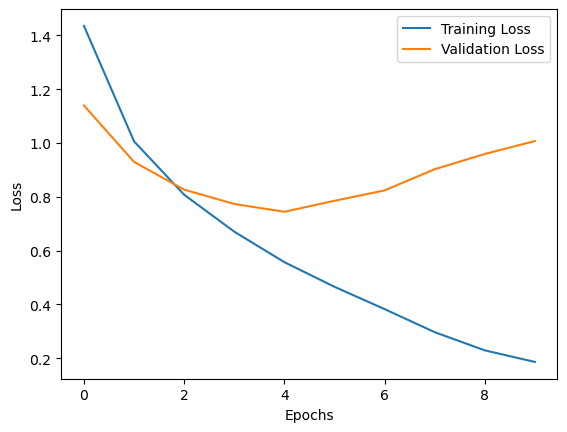

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses,
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [8]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [9]:
# Evaluate our CNN on test set (using best saved model)

total = 0
correct = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print("Total values:", total)
print("Correct values:", correct)
print(f"accuracy = {correct/total * 100:.2f}%")

Total values: 10000
Correct values: 7375
accuracy = 73.75%
